In [14]:
# !pip install numpy opencv-python matplotlib scikit-image scikit-learn pandas

In [1]:
# This ensures plots display in Jupyter
%matplotlib inline

# Import required libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.segmentation import active_contour
from skimage.filters import gaussian
from sklearn.cluster import MeanShift

### Utility function to display images

In [2]:
def show_image(title, image, cmap='gray'):
    plt.figure(figsize=(5,5))
    plt.title(title)
    plt.imshow(image, cmap=cmap)
    plt.axis('off')

#### Load MRI Image

Image loaded successfully


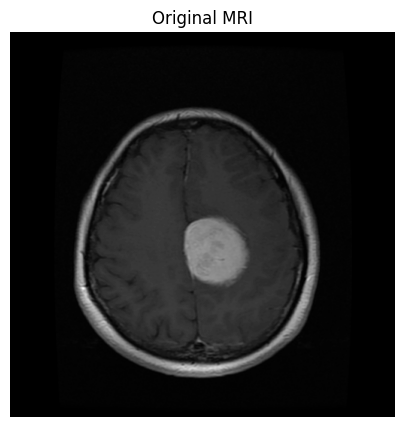

In [3]:
# Load MRI image
image = cv2.imread('data/mri1_data.png', 0)

if image is None:
    print("ERROR: Image not found. Check path!")
else:
    print("Image loaded successfully")

# Normalize
image = image / 255.0

# Show image
show_image("Original MRI", image)

##### Active Contour (Snakes)

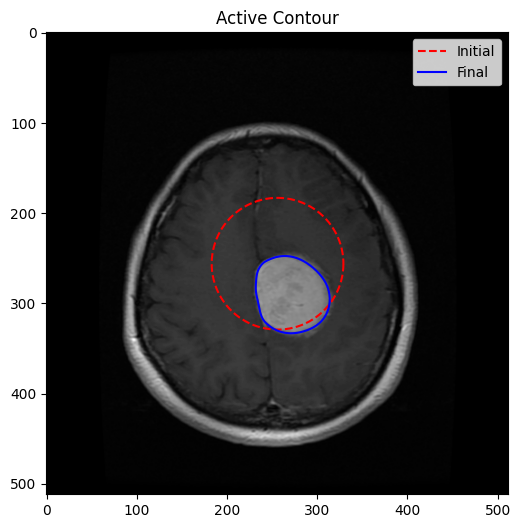

In [ ]:
# Active Contour
# Smooth image
image_smooth = gaussian(image, sigma=2)

# Initial contour (circle)
h, w = image.shape

radius = min(h, w) // 7   # increase range

s = np.linspace(0, 2*np.pi, 400)
r = h//2 + radius * np.sin(s)
c = w//2 + radius * np.cos(s)

init = np.array([r, c]).T


# Apply snake
snake = active_contour(
    image_smooth,
    init,
    alpha=0.01,
    beta=2,
    gamma=0.005
)

# Plot
plt.figure(figsize=(6,6))
plt.imshow(image, cmap='gray')
plt.plot(init[:, 1], init[:, 0], '--r', label='Initial')
plt.plot(snake[:, 1], snake[:, 0], '-b', label='Final')
plt.title("Active Contour")
plt.legend()
plt.show()

#### Mean Shift Segmentation

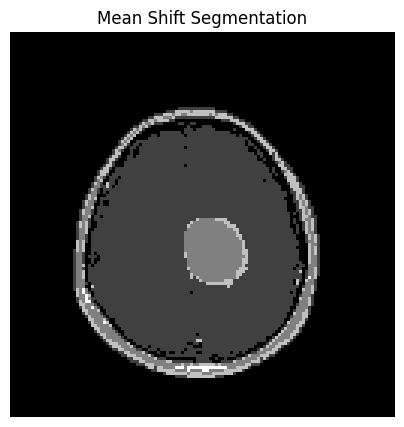

In [ ]:
# Mean Shift Segmentation
# Convert image to 2D feature space
# Resize image to speed up
image_small = cv2.resize(image, (128, 128))

flat_image = image_small.reshape(-1, 1)

# Apply Mean Shift
ms = MeanShift(bandwidth=0.1)
ms.fit(flat_image)

labels = ms.labels_
segmented = labels.reshape(image_small.shape)

show_image("Mean Shift Segmentation", segmented)

#### Split and Merge Segmentation

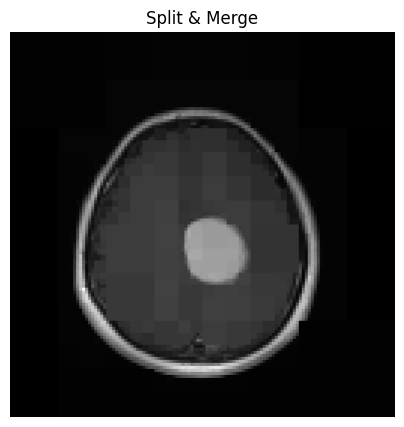

In [ ]:
# Split and Merge Segmentation
def split_and_merge(img, threshold=0.001):
    h, w = img.shape
    output = np.zeros_like(img)

    def split(x, y, size):
        region = img[x:x+size, y:y+size]

        if np.var(region) < threshold or size < 8:
            output[x:x+size, y:y+size] = np.mean(region)
        else:
            half = size // 2
            split(x, y, half)
            split(x+half, y, half)
            split(x, y+half, half)
            split(x+half, y+half, half)

    split(0, 0, min(h, w))
    return output

split_merge_result = split_and_merge(image)

show_image("Split & Merge", split_merge_result)

#### Level Set (Approximation using contours)

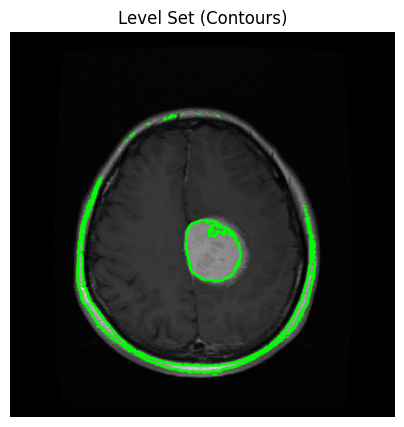

In [ ]:
# Level Set
# We simulate level set using contour detection

# Convert to binary
_, thresh = cv2.threshold((image*255).astype(np.uint8), 127, 255, cv2.THRESH_BINARY)

# Find contours
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Draw contours
level_set_img = cv2.cvtColor((image*255).astype(np.uint8), cv2.COLOR_GRAY2BGR)
cv2.drawContours(level_set_img, contours, -1, (0,255,0), 2)

show_image("Level Set (Contours)", level_set_img, cmap=None)

#### PERFORMANCE COMPARISON

In [9]:
import time
import pandas as pd

# Metrics Function
def compute_metrics(pred, gt):
    pred = pred.astype(bool)
    gt = gt.astype(bool)

    TP = np.sum(np.logical_and(pred, gt))
    TN = np.sum(np.logical_and(~pred, ~gt))
    FP = np.sum(np.logical_and(pred, ~gt))
    FN = np.sum(np.logical_and(~pred, gt))

    iou = TP / (TP + FP + FN) if (TP + FP + FN) != 0 else 0
    dice = (2 * TP) / (2 * TP + FP + FN) if (2 * TP + FP + FN) != 0 else 0
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0

    return iou, dice, accuracy, precision, recall


# Load Ground Truth
gt = cv2.imread('data/mri1_data_mask.png', 0)

if gt is None:
    print("Ground truth not found!")
else:
    gt = gt > 127

    results = []

    # 1. ACTIVE CONTOUR (FIXED → FILLED MASK)
    try:
        start = time.time()

        # Convert snake to closed contour
        snake_pts = snake.astype(np.int32)

        # Create mask
        snake_mask = np.zeros_like(image, dtype=np.uint8)
        cv2.fillPoly(snake_mask, [snake_pts[:, ::-1]], 1)  # (y,x) → (x,y)

        # Resize
        snake_mask = cv2.resize(snake_mask, (gt.shape[1], gt.shape[0]), interpolation=cv2.INTER_NEAREST)

        iou, dice, acc, prec, rec = compute_metrics(snake_mask, gt)
        t = time.time() - start

        results.append(["Active Contour", iou, dice, acc, prec, rec, t])

    except Exception as e:
        print("Snake error:", e)
        results.append(["Active Contour", 0, 0, 0, 0, 0, 0])


    # 2. MEAN SHIFT (FIXED → BEST CLUSTER SELECTION)
    try:
        start = time.time()

        labels = np.unique(segmented)

        best_iou = 0
        best_mask = None

        for label in labels:
            temp = (segmented == label).astype(np.uint8)
            temp = cv2.resize(temp, (gt.shape[1], gt.shape[0]))

            iou_temp = compute_metrics(temp > 0, gt)[0]

            if iou_temp > best_iou:
                best_iou = iou_temp
                best_mask = temp

        pred = best_mask > 0

        iou, dice, acc, prec, rec = compute_metrics(pred, gt)
        t = time.time() - start

        results.append(["Mean Shift", iou, dice, acc, prec, rec, t])

    except Exception as e:
        print("Mean Shift error:", e)
        results.append(["Mean Shift", 0, 0, 0, 0, 0, 0])


    # 3. SPLIT & MERGE
    try:
        start = time.time()

        split_norm = cv2.normalize(split_merge_result, None, 0, 255, cv2.NORM_MINMAX)
        split_norm = split_norm.astype(np.uint8)

        pred = cv2.resize(split_norm, (gt.shape[1], gt.shape[0]))
        pred = pred > np.mean(pred)   # adaptive threshold

        iou, dice, acc, prec, rec = compute_metrics(pred, gt)
        t = time.time() - start

        results.append(["Split & Merge", iou, dice, acc, prec, rec, t])

    except Exception as e:
        print("Split error:", e)
        results.append(["Split & Merge", 0, 0, 0, 0, 0, 0])


    # 4. LEVEL SET (Contours → FILLED MASK)
    try:
        start = time.time()

        contour_mask = np.zeros_like(gt, dtype=np.uint8)
        cv2.drawContours(contour_mask, contours, -1, 1, thickness=-1)

        iou, dice, acc, prec, rec = compute_metrics(contour_mask, gt)
        t = time.time() - start

        results.append(["Level Set", iou, dice, acc, prec, rec, t])

    except Exception as e:
        print("Level set error:", e)
        results.append(["Level Set", 0, 0, 0, 0, 0, 0])


    #DISPLAY TABLE
    df = pd.DataFrame(results, columns=[
        "Method", "IoU", "Dice", "Accuracy", "Precision", "Recall", "Time (sec)"
    ])

    print("\n FINAL SEGMENTATION COMPARISON\n")
    display(df)

    # METHOD
    best = df.loc[df["IoU"].idxmax()]

    print("\n🏆 BEST METHOD:")
    print(best["Method"])
    print("IoU:", best["IoU"])


 FINAL SEGMENTATION COMPARISON



,Method,IoU,Dice,Accuracy,Precision,Recall,Time (sec)
0,Active Contour,0.918331,0.957427,0.998081,0.993326,0.924032,0.001259
1,Mean Shift,0.458762,0.628975,0.976944,0.503786,0.836955,0.004375
2,Split & Merge,0.069684,0.130288,0.688267,0.069684,1.000000,0.003377
3,Level Set,0.432570,0.603908,0.977032,0.505507,0.749877,0.000933



🏆 BEST METHOD:
Active Contour
IoU: 0.9183308978730313


### VISUALIZATION

Ground truth loaded

 IoU Scores:

Active Contour: 0.9183
Mean Shift: 0.4588
Split & Merge: 0.0697
Level Set: 0.4326


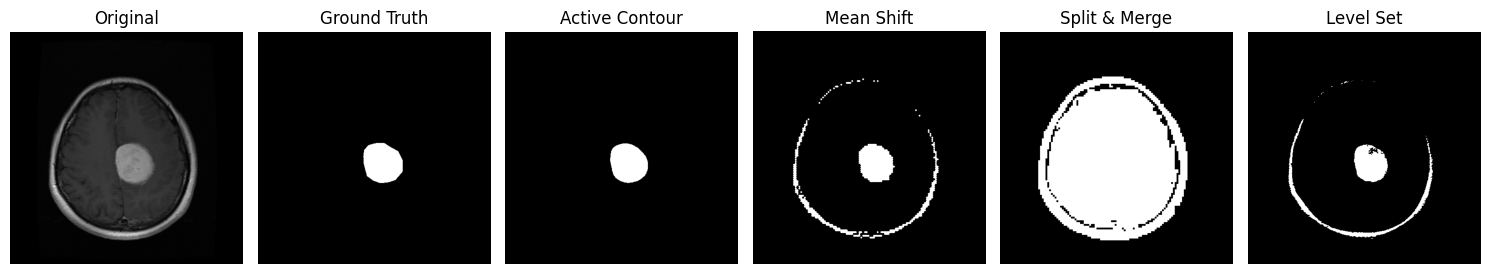

In [ ]:
import matplotlib.pyplot as plt

# IoU Function
def compute_iou(pred, gt):
    intersection = np.logical_and(pred, gt)
    union = np.logical_or(pred, gt)
    return np.sum(intersection) / np.sum(union) if np.sum(union) != 0 else 0


# Load Ground Truth
gt = cv2.imread('data/mri1_data_mask.png', 0)

if gt is None:
    print("Ground truth not found!")
else:
    print("Ground truth loaded")

    gt = gt > 127

    methods_dict = {}

    # 1. ACTIVE CONTOUR
    try:
        snake_mask = np.zeros_like(image, dtype=np.uint8)
        cv2.fillPoly(snake_mask, [snake.astype(np.int32)[:, ::-1]], 1)

        pred_snake = cv2.resize(snake_mask, (gt.shape[1], gt.shape[0]))
        methods_dict["Active Contour"] = pred_snake > 0

    except:
        print("Active Contour failed")


    # 2. MEAN SHIFT (BEST CLUSTER)
    try:
        labels = np.unique(segmented)

        best_iou = 0
        best_mask = None

        for label in labels:
            temp = (segmented == label).astype(np.uint8)
            temp = cv2.resize(temp, (gt.shape[1], gt.shape[0]))

            iou_temp = compute_iou(temp > 0, gt)

            if iou_temp > best_iou:
                best_iou = iou_temp
                best_mask = temp

        methods_dict["Mean Shift"] = best_mask > 0

    except:
        print("Mean Shift failed")


    # 3. SPLIT & MERGE
    try:
        split_norm = cv2.normalize(split_merge_result, None, 0, 255, cv2.NORM_MINMAX)
        split_norm = split_norm.astype(np.uint8)

        pred_sm = cv2.resize(split_norm, (gt.shape[1], gt.shape[0]))
        pred_sm = pred_sm > np.mean(pred_sm)

        methods_dict["Split & Merge"] = pred_sm

    except:
        print("Split & Merge failed")


    # 4. LEVEL SET (Contours)
    try:
        contour_mask = np.zeros_like(gt, dtype=np.uint8)
        cv2.drawContours(contour_mask, contours, -1, 1, thickness=-1)

        methods_dict["Level Set"] = contour_mask > 0

    except:
        print("Level Set failed")


    # PRINT IoU + SHOW OUTPUTS
    print("\n IoU Scores:\n")

    plt.figure(figsize=(15, 5))

    # Show Original + GT
    plt.subplot(1, len(methods_dict) + 2, 1)
    plt.title("Original")
    plt.imshow(image, cmap='gray')
    plt.axis('off')

    plt.subplot(1, len(methods_dict) + 2, 2)
    plt.title("Ground Truth")
    plt.imshow(gt, cmap='gray')
    plt.axis('off')

    i = 3

    for method_name, pred in methods_dict.items():
        iou = compute_iou(pred, gt)
        print(f"{method_name}: {iou:.4f}")

        plt.subplot(1, len(methods_dict) + 2, i)
        plt.title(method_name)
        plt.imshow(pred, cmap='gray')
        plt.axis('off')

        i += 1

    plt.tight_layout()
    plt.show()